# Data & Libraries

In [60]:
import sys
sys.path.insert(1,'../Bike_Sharing_Demande/DATA/train.csv')

# Import Dependencies
%matplotlib inline

# Start Python Imports
import math, time, random
from datetime import datetime 
import calendar

# Data Manipulation
import numpy as np
import pandas as pd

# Visualization 
import matplotlib.pyplot as plt
import missingno
import seaborn as sns
plt.style.use('seaborn-whitegrid')

# Preprocessing
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, label_binarize

# Machine learning
import catboost
from sklearn.model_selection import train_test_split
from sklearn import model_selection, tree, preprocessing, metrics, linear_model
from sklearn.svm import LinearSVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LinearRegression, LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from catboost import CatBoostClassifier, Pool, cv

# Let's be rebels and ignore warnings for now
import warnings
warnings.filterwarnings('ignore')

In [61]:
train_df = pd.read_csv('../Bike_Sharing_Demande/DATA/train.csv')
test_df = pd.read_csv('../Bike_Sharing_Demande/DATA/test.csv')
sample_df = pd.read_csv('../Bike_Sharing_Demande/DATA/sampleSubmission.csv')

# Analyse
Description des données :
- datetime - hourly date + timestamp  
- season -  1 = spring, 2 = summer, 3 = fall, 4 = winter 
- holiday - whether the day is considered a holiday
- workingday - whether the day is neither a weekend nor holiday
- weather - 
    - 1: Clear, Few clouds, Partly cloudy, Partly cloudy
    - 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
    - 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
    - 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog 
- temp - temperature in Celsius
- atemp - "feels like" temperature in Celsius
- humidity - relative humidity
- windspeed - wind speed
- casual - number of non-registered user rentals initiated
- registered - number of registered user rentals initiated
- count - number of total rentals

In [62]:
train_df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [63]:
test_df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed
0,2011-01-20 00:00:00,1,0,1,1,10.66,11.365,56,26.0027
1,2011-01-20 01:00:00,1,0,1,1,10.66,13.635,56,0.0000
2,2011-01-20 02:00:00,1,0,1,1,10.66,13.635,56,0.0000
3,2011-01-20 03:00:00,1,0,1,1,10.66,12.880,56,11.0014
4,2011-01-20 04:00:00,1,0,1,1,10.66,12.880,56,11.0014


## Feature Engineering 

In [64]:
# Création d'une nouvelle colonne date 
train_df['date']= train_df.datetime.apply(lambda x: x.split()[0])
train_df['hour'] = train_df.datetime.apply(lambda x: x.split()[1].split(":")[0])
train_df['weekday'] = train_df.date.apply(lambda dateString : calendar.day_name[datetime.strptime(dateString,"%Y-%m-%d").weekday()])
train_df['month'] = train_df.date.apply(lambda dateString : calendar.month_name[datetime.strptime(dateString,"%Y-%m-%d").weekday()])
train_df['season'] = train_df.season.map({1: "Spring", 2: "Summer",3: "Fall",4: "Winter"})
train_df["weather"] = train_df.weather.map({1: " Clear + Few clouds + Partly cloudy + Partly cloudy",\
                                        2 : " Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist ", \
                                        3 : " Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds", \
                                        4 :" Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog " })

In [65]:
train_df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,hour,weekday,month
0,2011-01-01 00:00:00,Spring,0,0,Clear + Few clouds + Partly cloudy + Partly cloudy,9.84,14.395,81,0.0000,3,13,16,2011-01-01,00,Saturday,May
1,2011-01-01 01:00:00,Spring,0,0,Clear + Few clouds + Partly cloudy + Partly cloudy,9.02,13.635,80,0.0000,8,32,40,2011-01-01,01,Saturday,May
2,2011-01-01 02:00:00,Spring,0,0,Clear + Few clouds + Partly cloudy + Partly cloudy,9.02,13.635,80,0.0000,5,27,32,2011-01-01,02,Saturday,May
3,2011-01-01 03:00:00,Spring,0,0,Clear + Few clouds + Partly cloudy + Partly cloudy,9.84,14.395,75,0.0000,3,10,13,2011-01-01,03,Saturday,May
4,2011-01-01 04:00:00,Spring,0,0,Clear + Few clouds + Partly cloudy + Partly cloudy,9.84,14.395,75,0.0000,0,1,1,2011-01-01,04,Saturday,May
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,Winter,0,1,Clear + Few clouds + Partly cloudy + Partly cloudy,15.58,19.695,50,26.0027,7,329,336,2012-12-19,19,Wednesday,February
10882,2012-12-19 20:00:00,Winter,0,1,Clear + Few clouds + Partly cloudy + Partly cloudy,14.76,17.425,57,15.0013,10,231,241,2012-12-19,20,Wednesday,February
10883,2012-12-19 21:00:00,Winter,0,1,Clear + Few clouds + Partly cloudy + Partly cloudy,13.94,15.910,61,15.0013,4,164,168,2012-12-19,21,Wednesday,February
10884,2012-12-19 22:00:00,Winter,0,1,Clear + Few clouds + Partly cloudy + Partly cloudy,13.94,17.425,61,6.0032,12,117,129,2012-12-19,22,Wednesday,February


In [66]:
# Conversion en type categorical 
categoryVariableList = ['hour','weekday','month','season','weather','holiday','workingday']

for var in categoryVariableList:
    train_df[var] = train_df[var].astype("category")

In [70]:
# Drop date columns 
train_df = train_df.drop(['datetime'], axis = 1 )

## Missing value 

<AxesSubplot:>

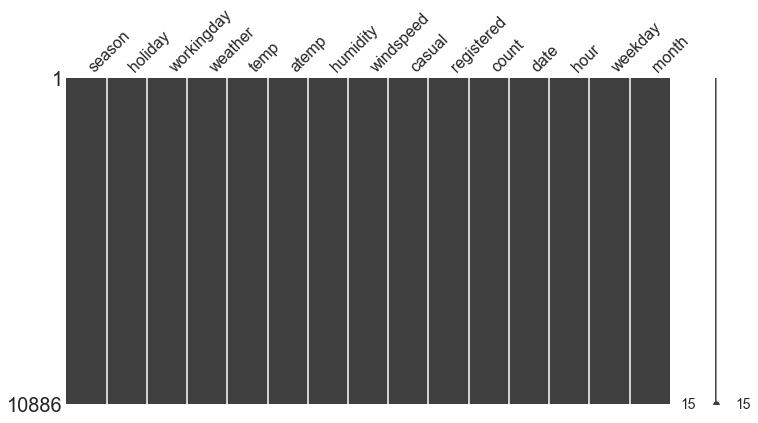

In [72]:
missingno.matrix(train_df,figsize=(12,6))

## Outliers

<AxesSubplot:ylabel='count'>

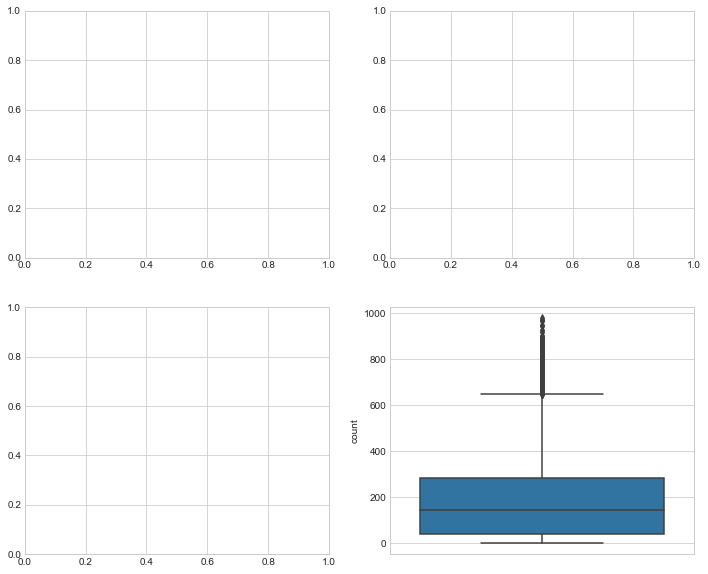

In [79]:
fig, axes = plt.subplots(nrows = 2, ncols = 2)
fig.set_size_inches(12,10)


# Fonction boxplot dat
sns.boxplot(data = train_df,y = 'count',orient = 'v',ax = axes[0][0])